## Supp Fig2K: MSigDB Pathways on Differential Proteins against HCs

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(stringr)
  library(ggplot2)
})

In [2]:
msigdbPathways_healthy <- fread('../../data/figure-inputs/olink/cross-sectional-msigdb-pathways-on-healthy-comparisons.csv')

In [3]:
tp_color_map <- c(
  'PreTx'    = '#8B0000',
  'PI2C'     = '#C20272',
  'EI'       = '#7502C2',
  'ASCT60d'  = '#0021B0',
  'ASCT90d'  = '#2346DE',
  'ASCT1y'   = '#038AFF',
  'ASCT2y'   = '#008080',
  'Healthy'  = '#00470D'
)

In [4]:
msigdbPathways_healthy$tp <- sub("-Healthy$", "", msigdbPathways_healthy$Contrast)
msigdb_Healthy <- ggplot(
  msigdbPathways_healthy[!is.na(msigdbPathways_healthy$FDR)],
  aes(y = reorder(str_wrap(geneSet, width = 50), -log10(FDR)),
      x = -log10(FDR),
      fill = tp)
) +
  geom_bar(stat = "identity", color = "black", linewidth = 0.3, alpha = 0.7) +
  facet_wrap(~ Contrast, nrow = 1) +
  scale_fill_manual(values = tp_color_map, guide = "none") +
  labs(
    x = "-log10(FDR)",
    y = "Gene Set",
    title = ""
  ) +
  theme_linedraw(base_size = 20) +
  theme(
    axis.text.x = element_text(size = 14, angle = 90),
    axis.text.y = element_text(size = 15),
    strip.text = element_text(hjust = 0.5, size = 12, color = 'black'),
    strip.background = element_blank(),
    axis.line = element_blank(), 
    panel.grid.major = element_line(color = "black"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1)
  )

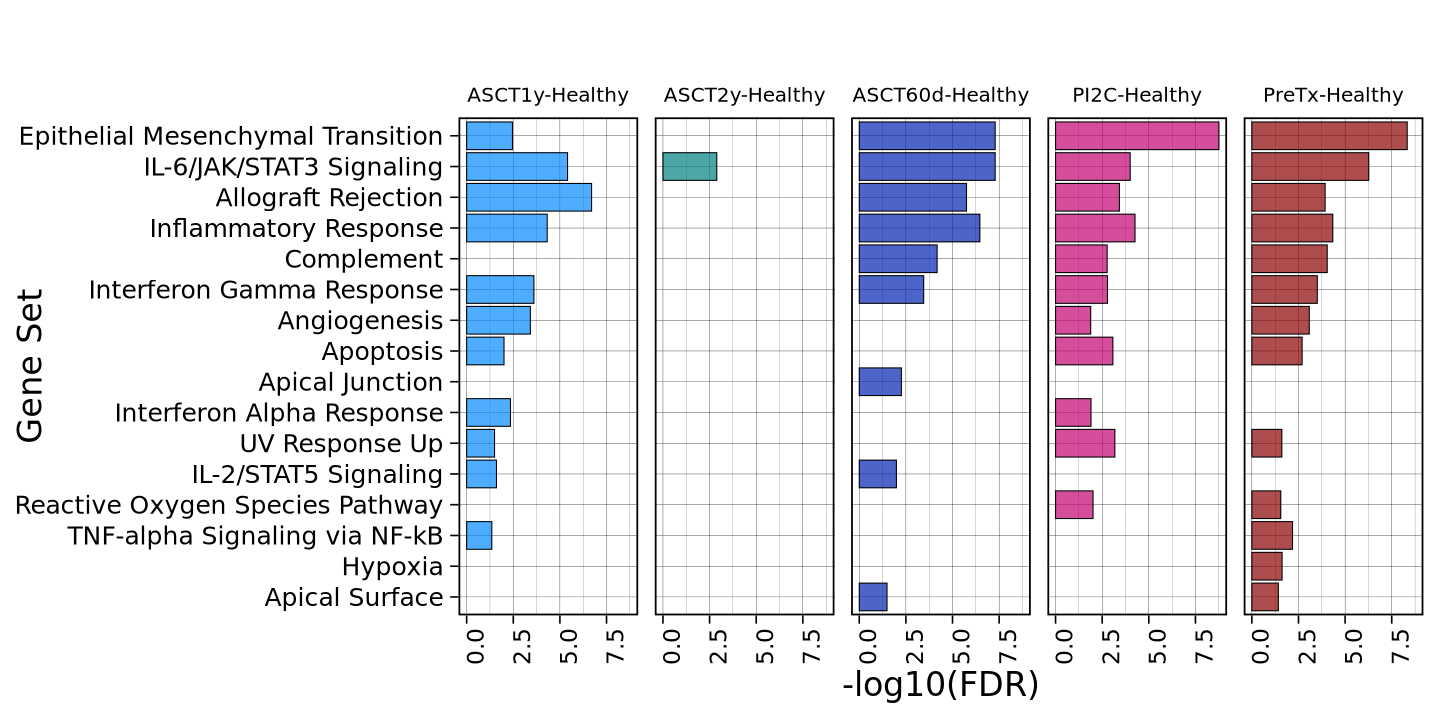

In [5]:
options(repr.plot.width = 12, repr.plot.height = 6)
msigdb_Healthy

In [6]:
ggsave("../../data/figure-outputs/supplementary-2/sup_2k.pdf", plot = msigdb_Healthy, width = 12, height = 6, dpi = 200, device = cairo_pdf)